<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
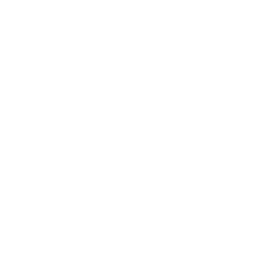
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kodierung unerwünschter Ereignisse in klinischen Studien</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmazeutik / Arzneimittelsicherheitsüberwachung &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Datensätze zu unerwünschten Ereignissen liegen mit wörtlichen MedDRA-Bevorzugten-Begriffen
vor, doch regulatorische Sicherheitstabellen sind nach Systemorganklasse (SOC) gegliedert.
Dieses Beispiel erstellt mit PROC FORMAT einen Wertformat, das jeden bevorzugten Begriff
seiner SOC zuordnet, und verwendet dieses eine Format zur Steuerung jeder nachgelagerten
Auswertung: eine PROC FREQ Kreuztabelle von SOC nach Behandlungsarm, eine Aufschlüsselung
SOC nach Schweregrad und eine Zusammenfassung der schwerwiegenden unerwünschten Ereignisse.
Da die Zuordnung ausschließlich im Format liegt, ist die Umstellung der Studie auf eine neue
MedDRA-Version eine einzige Formatänderung statt einer Überarbeitung jedes Berichts. ODS OUTPUT
erfasst die SOC-Häufigkeiten als Datensatz für die nachgelagerte Signalprüfung.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------:|
| WORK.AE_RAW | Synthetische Datensätze unerwünschter Ereignisse mit MedDRA-Bevorzugten-Begriffen | 100 |
| WORK.RANDOMIZATION | Zuordnung der Studienteilnehmer zum Behandlungsarm | 100 |

Die Umgebung läuft unlizenziert, daher ist jede erzeugte Tabelle auf 100 Beobachtungen
begrenzt. Das Szenario ist auf diese Grenze zugeschnitten: 100 unerwünschte Ereignisse aus
einem 12-Term-MedDRA-Panel, wie es für eine onkologische Studie typisch ist.

---

In [1]:
/* --------------------------------------------------------
   Synthetischen Datensatz unerwuenschter Ereignisse erzeugen
   MedDRA-Bevorzugte-Begriffe werden SOC-Kategorien zugeordnet
   -------------------------------------------------------- */
DATEN work.ae_raw;
    AUFRUFEN streaminit(42);
    LÄNGE aedecod $30;
    FELD pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    FELD sev_list[3] $10 _temporary_ ('LEICHT' 'MITTEL' 'SCHWER');
    AUSFÜHRUNG i = 1 BIS 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        /* Deutsche Bezeichnung ueber IF/ELSE zugewiesen (nicht ueber
           ein _temporary_-Array), um nicht-ASCII-Werte sicher zu halten */
        WENN pt_idx = 1 DANN aedecod = 'Übelkeit';
        SONST WENN pt_idx = 2 DANN aedecod = 'Kopfschmerzen';
        SONST WENN pt_idx = 3 DANN aedecod = 'Erbrechen';
        SONST WENN pt_idx = 4 DANN aedecod = 'Durchfall';
        SONST WENN pt_idx = 5 DANN aedecod = 'Husten';
        SONST WENN pt_idx = 6 DANN aedecod = 'Müdigkeit';
        SONST WENN pt_idx = 7 DANN aedecod = 'Gelenkschmerzen';
        SONST WENN pt_idx = 8 DANN aedecod = 'Fieber';
        SONST WENN pt_idx = 9 DANN aedecod = 'Bauchschmerzen';
        SONST WENN pt_idx = 10 DANN aedecod = 'Neutropenie';
        SONST WENN pt_idx = 11 DANN aedecod = 'Febrile Neutropenie';
        SONST aedecod = 'Infusionsbedingte Reaktion';
        sev_idx = int(rand('uniform') * 3) + 1;
        WENN pt_idx in (10, 11) DANN sev_idx = MAX(sev_idx, 2);
        aesev = sev_list[sev_idx];
        aeser = ifc(aesev = 'SCHWER' UND rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        WENN aestdy > 365 DANN aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', PUT(int(rand('uniform') * 25) + 1, z3.));
        AUSGABE;
    ENDE;
    ENTFERNEN i pt_idx sev_idx;
AUSFÜHREN;


NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.71 seconds
  cpu   1.71 seconds


In [2]:
/* --------------------------------------------------------
   Randomisierungstabelle der Studienteilnehmer erzeugen
   -------------------------------------------------------- */
DATEN work.randomization;
    AUFRUFEN streaminit(43);
    LÄNGE treatment_arm $24;
    AUSFÜHRUNG subject_id = 1 BIS 800;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        /* Deutsche Bezeichnung ueber IF/ELSE zugewiesen (nicht ueber
           ein _temporary_-Array), um nicht-ASCII-Werte sicher zu halten */
        WENN arm_idx = 1 DANN treatment_arm = 'Prüfarm';
        SONST WENN arm_idx = 2 DANN treatment_arm = 'Aktive Vergleichsgruppe';
        SONST treatment_arm = 'Placebo';
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        AUSGABE;
    ENDE;
    ENTFERNEN arm_idx;
    format randomization_date date9.;
AUSFÜHREN;


NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                Rohe Häufigkeit bevorzugter Begriffe (nicht zugeordnet)                                 

                                                   The FREQ Procedure

Bevorzugter Begriff           Frequency    Percent
---------------------------------------------------
Durchfall                            12     12.00
Kopfschmerzen                        12     12.00
Fieber                               11     11.00
Müdigkeit                            11     11.00
Gelenkschmerzen                      10     10.00
Übelkeit                             10     10.00
Infusionsbedingte Reaktion            8      8.00
Husten                                7      7.00
Bauchschmerzen                        5      5.00
Febrile Neutropenie                   5      5.00
Neutropenie                           5      5.00
Erbrechen                             4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


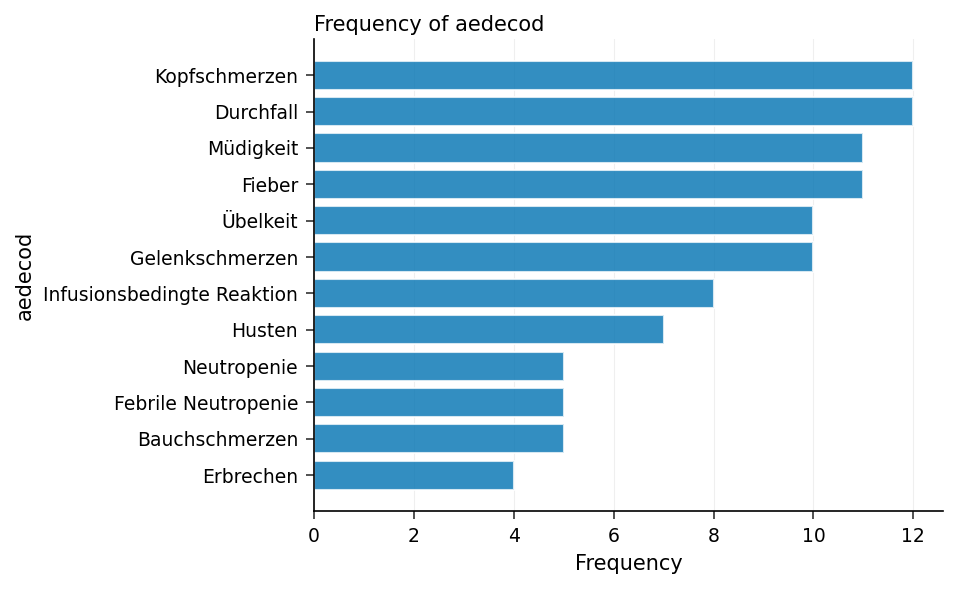

In [3]:
/* --------------------------------------------------------
   Haeufigkeit der unbearbeiteten bevorzugten Begriffe vor der
   SOC-Zuordnung
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.ae_raw ORDER=HÄUFIGKEITEN;
    TABLES aedecod / nocum;
    BEZEICHNUNG aedecod = "Bevorzugter Begriff";
    TITEL "Rohe Häufigkeit bevorzugter Begriffe (nicht zugeordnet)";
AUSFÜHREN;

---

                                Rohe Häufigkeit bevorzugter Begriffe (nicht zugeordnet)                                 




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


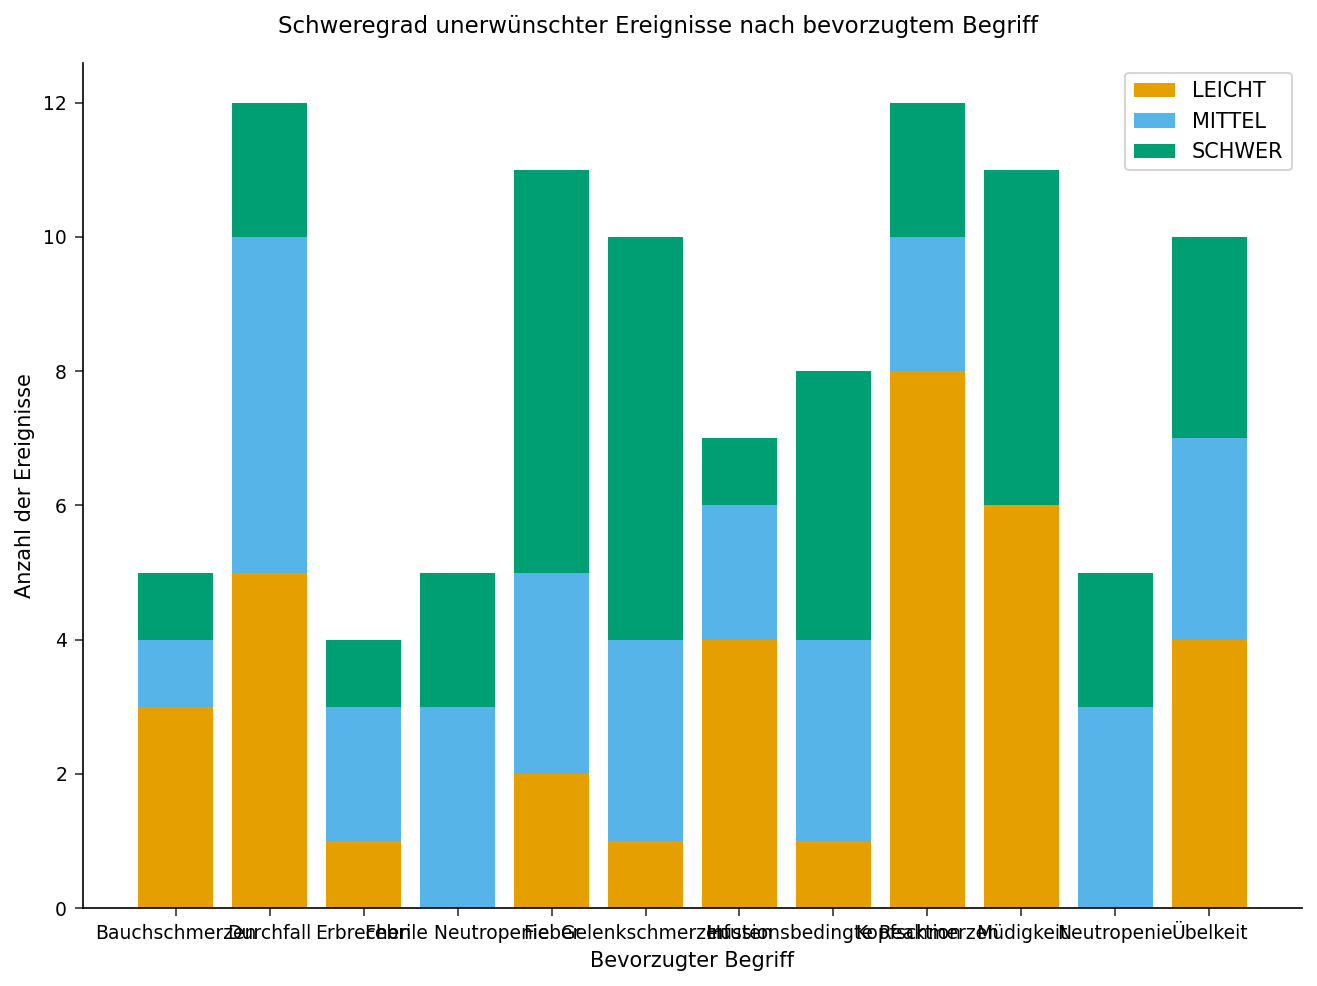

In [4]:
/* --------------------------------------------------------
   Verteilung des Schweregrads unerwuenschter Ereignisse nach
   bevorzugtem Begriff
   -------------------------------------------------------- */
PROZEDUR SGPLOT DATEN=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS BEZEICHNUNG="Bevorzugter Begriff" fitpolicy=ROTATE;
    YAXIS BEZEICHNUNG="Anzahl der Ereignisse";
    TITEL "Schweregrad unerwünschter Ereignisse nach bevorzugtem Begriff";
AUSFÜHREN;

---

In [5]:
/* --------------------------------------------------------
   Definiert das Wertformat MedDRA-Bevorzugter-Begriff -> System-
   organklasse. Das Format ist ueber den Text des bevorzugten
   Begriffs indiziert, sodass ein einziger PUT()-Aufruf jeden
   AE-Datensatz seiner SOC zuordnet.
   -------------------------------------------------------- */
PROZEDUR format;
    VALUE $pt_to_soc
        'Übelkeit'                    = 'Erkrankungen des Gastrointestinaltrakts'
        'Erbrechen'                   = 'Erkrankungen des Gastrointestinaltrakts'
        'Durchfall'                   = 'Erkrankungen des Gastrointestinaltrakts'
        'Bauchschmerzen'              = 'Erkrankungen des Gastrointestinaltrakts'
        'Kopfschmerzen'               = 'Erkrankungen des Nervensystems'
        'Müdigkeit'                   = 'Allgemeine Erkrankungen'
        'Fieber'                      = 'Allgemeine Erkrankungen'
        'Husten'                      = 'Erkrankungen der Atemwege'
        'Gelenkschmerzen'             = 'Erkrankungen des Skelettmuskelsystems'
        'Neutropenie'                 = 'Erkrankungen des Blutes und des Lymphsystems'
        'Febrile Neutropenie'         = 'Erkrankungen des Blutes und des Lymphsystems'
        'Infusionsbedingte Reaktion'  = 'Erkrankungen des Immunsystems'
        OTHER                         = 'Nicht zugeordnet'
    ;
    VALUE $sev_rank
        'LEICHT'   = '1-Leicht'
        'MITTEL'   = '2-Mittel'
        'SCHWER'   = '3-Schwer'
        OTHER      = '9-Unbekannt'
    ;
    VALUE $serious_fmt
        'Y' = 'Schwerwiegend'
        'N' = 'Nicht schwerwiegend'
    ;
AUSFÜHREN;


NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   AE-Datensaetze mit dem Behandlungsarm zusammenfuehren und dann
   das SOC-Format anwenden. PUT(aedecod, $pt_to_soc.) ist der
   einzige noetige Zuordnungsschritt; Schweregrad und Schwere-
   wiegend-Kennzeichen werden ebenso kodiert.
   -------------------------------------------------------- */
PROZEDUR SORTIEREN DATEN=work.ae_raw; NACH usubjid; AUSFÜHREN;
PROZEDUR SORTIEREN DATEN=work.randomization; NACH usubjid; AUSFÜHREN;

DATEN work.ae_coded;
    ZUSAMMENFÜHREN work.ae_raw (in=a)
          work.randomization (in=b BEHALTEN=usubjid treatment_arm);
    NACH usubjid;
    WENN a;
    soc_class     = PUT(aedecod, $pt_to_soc.);
    severity_rank = PUT(aesev,   $sev_rank.);
    serious_flag  = PUT(aeser,   $serious_fmt.);
AUSFÜHREN;


NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


                                AE-Häufigkeit nach Systemorganklasse und Behandlungsarm                                 

                                                   The FREQ Procedure

Table of Systemorganklasse by Behandlungsarm

Systemorganklasse                            |Aktive Vergleichsgruppe |                Placebo |                Prüfarm |                   Total
---------------------------------------------+------------------------+------------------------+------------------------+------------------------
Allgemeine Erkrankungen                      |                      1 |                      3 |                      1 |                       5
---------------------------------------------+------------------------+------------------------+------------------------+------------------------
Erkrankungen des Blutes und des Lymphsystems |                      0 |                      1 |                      1 |                       2
-------------------------------


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


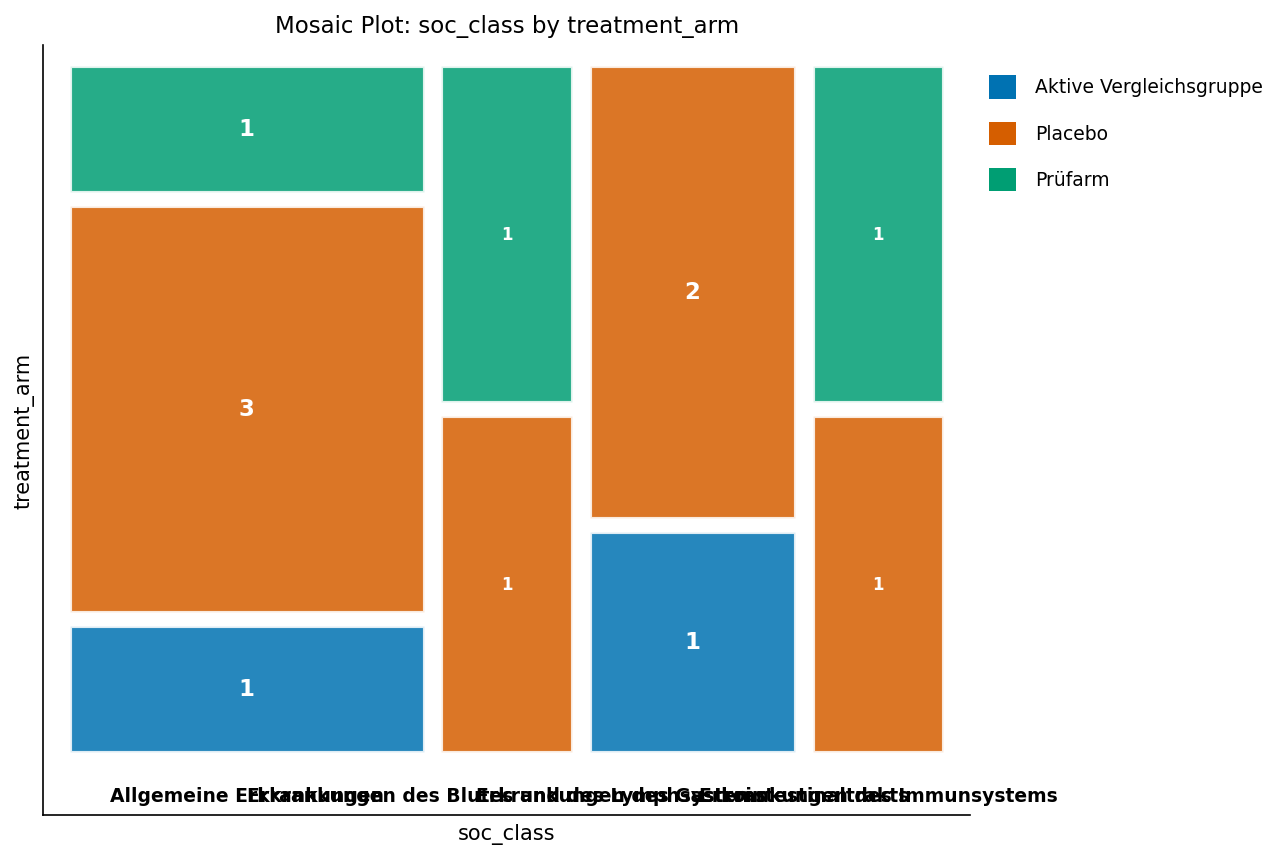

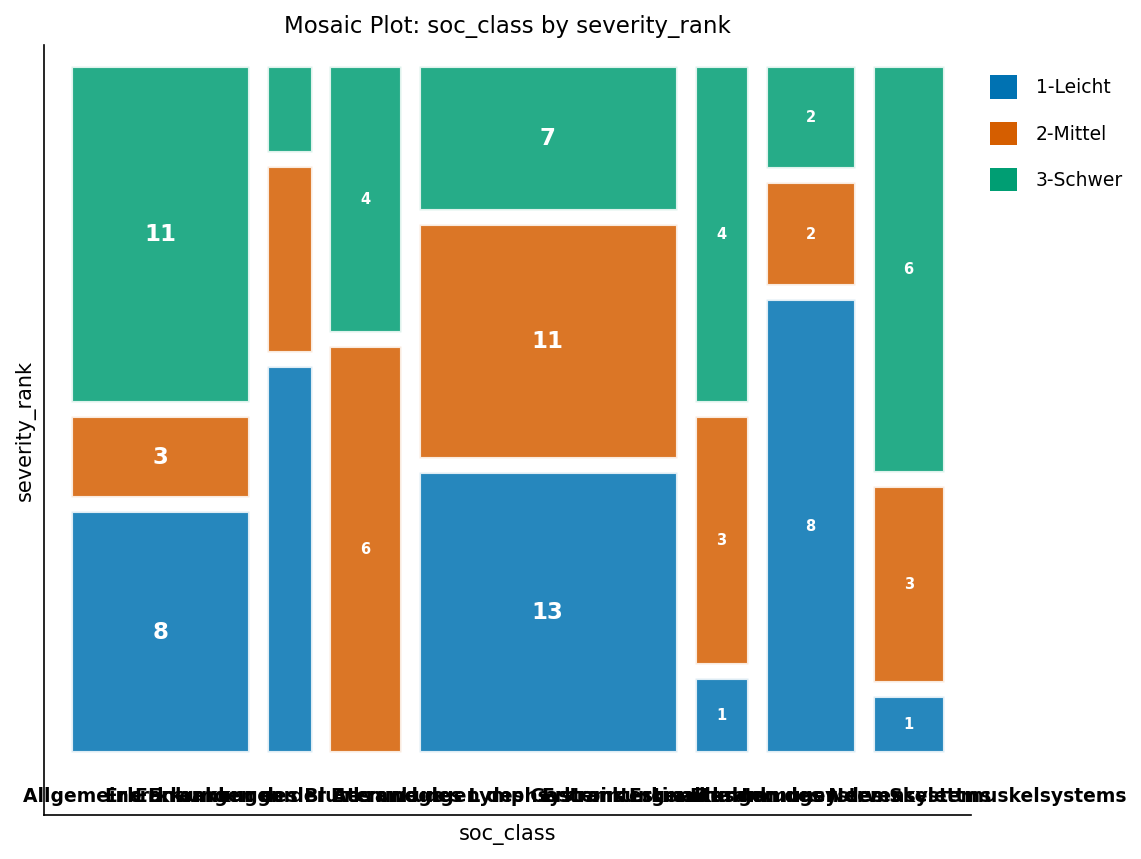

In [7]:
/* --------------------------------------------------------
   Haeufigkeit auf SOC-Ebene nach Behandlungsarm
   ODS OUTPUT erfasst die Ergebnisse zur Signalerkennung
   -------------------------------------------------------- */
ODS AUSGABE onewayfreqs=work.soc_freq_table;

PROZEDUR HÄUFIGKEITEN DATEN=work.ae_coded ORDER=HÄUFIGKEITEN;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    BEZEICHNUNG soc_class="Systemorganklasse" treatment_arm="Behandlungsarm"
          severity_rank="Schweregrad";
    TITEL "AE-Häufigkeit nach Systemorganklasse und Behandlungsarm";
AUSFÜHREN;

ODS AUSGABE CLOSE;

                    Schwerwiegende unerwünschte Ereignisse nach Systemorganklasse und Behandlungsarm                    

                                                   The FREQ Procedure

Table of Systemorganklasse by Behandlungsarm

Systemorganklasse             |Aktive Vergleichsgruppe |                Placebo |                Prüfarm |                   Total
------------------------------+------------------------+------------------------+------------------------+------------------------
Allgemeine Erkrankungen       |                      1 |                      1 |                      1 |                       3
------------------------------+------------------------+------------------------+------------------------+------------------------
Erkrankungen des Immunsystems |                      0 |                      1 |                      0 |                       1
------------------------------+------------------------+------------------------+------------------------+


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


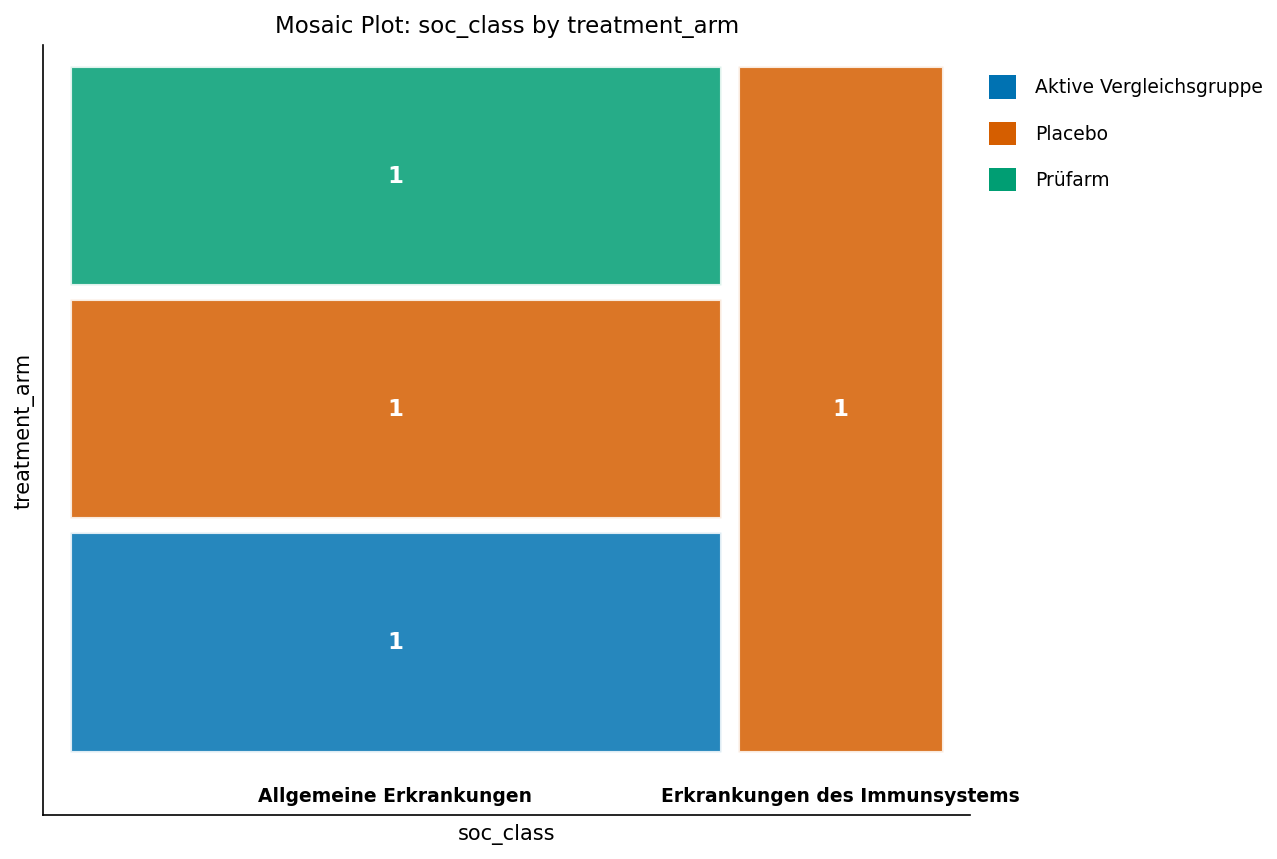

In [8]:
/* --------------------------------------------------------
   Zusammenfassung der schwerwiegenden unerwuenschten Ereignisse
   nach SOC fuer die Sicherheitsnarrative
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.ae_coded;
    WO aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    BEZEICHNUNG soc_class="Systemorganklasse" treatment_arm="Behandlungsarm";
    TITEL "Schwerwiegende unerwünschte Ereignisse nach Systemorganklasse und Behandlungsarm";
AUSFÜHREN;

---

### Interpretation

Ein einziges Wertformat `$pt_to_soc` hat alle 100 unerwünschten Ereignisse aus 12 wörtlichen
MedDRA-Bevorzugten-Begriffen in 7 Systemorganklassen kodiert, und genau dieses eine Format hat
jede nachstehende Tabelle gesteuert, ohne die Daten neu zu kodieren.

Nach SOC und Schweregrad ist **Erkrankungen des Gastrointestinaltrakts** die häufigste Klasse
mit 31 von 100 Ereignissen (13 leicht, 11 mittel, 7 schwer), gefolgt von **Allgemeine
Erkrankungen** mit 22 Ereignissen. Die übrigen Klassen sind kleiner: Erkrankungen des
Nervensystems (12), Erkrankungen des Blutes und des Lymphsystems (10), Erkrankungen des
Skelettmuskelsystems (10), Erkrankungen des Immunsystems (8) und Erkrankungen der Atemwege (7).
Über alle Ereignisse hinweg beträgt die Schweregradverteilung 35 leicht, 30 mittel und 35 schwer.

Nur 4 Ereignisse wurden als schwerwiegend gekennzeichnet (`aeser='Y'`): 3 in Allgemeine
Erkrankungen (eines pro Arm) und 1 in Erkrankungen des Immunsystems (Placebo). Die
Kreuztabelle SOC nach Behandlungsarm basiert auf den 12 Ereignissen, deren Studienteilnehmer
einem Randomisierungsdatensatz zugeordnet werden konnte, daher sind die Zahlen je Arm
illustrativ und nicht auf einen Armvergleich ausgelegt.

Die zentrale Erkenntnis ist der FORMAT-Mechanismus, nicht die synthetischen Zahlen: weil die
Zuordnung vom bevorzugten Begriff zur SOC vollständig in PROC FORMAT liegt, kodiert derselbe
Aufruf `PUT(aedecod, $pt_to_soc.)` den gesamten Datensatz neu, und die Umstellung auf eine neue
MedDRA-Wörterbuchversion bedeutet die Änderung eines Formats statt jedes Berichts. ODS OUTPUT
hat die SOC-Häufigkeiten als `work.soc_freq_table` für die nachgelagerte Signalprüfung erfasst.

---

In [9]:
/* --------------------------------------------------------
   SOC-kodierten AE-Datensatz fuer die Sicherheitssignalpruefung
   exportieren. Das eine Format $pt_to_soc hat soc_class befuellt,
   daher ist die exportierte Datei bereit fuer die nachgelagerte
   Analyse auf SOC-Ebene.
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>